# Regression Assignment

**Matrikelnummer:** 2130238  
**Datensatz:** `dataset_cleaned.csv` (Bankkunden-Daten)  
**Zielvariable:** `CLV_Continuous` (Customer Lifetime Value)

- **Task 2:** Multiple Lineare Regression
- **Task 3:** Polynomiale Regression (Grad 2 & 3)
- **Task 4:** Modellvergleich & Entscheidung
- **Task 5:** Regularisierung & Optimierung (Ridge & Lasso)
- **Task 6:** Regression Tree
- **Task 7:** Modellvergleich

---
## 1. Setup: Bibliotheken, Datensatz & Grundkonfiguration
Alle benötigten Bibliotheken werden einmalig importiert und der Datensatz geladen und Konstanten deklariert. Anschließend wird doe Feature-Matrix `X` und die Zielvariable `y` bestimmt sowie der Train-Test-Split definiert und in allen folgenden Aufgaben wiederverwendet.

In [1]:
# ── Bibliotheken ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import (
    KFold, GridSearchCV, train_test_split,
    cross_val_score, learning_curve
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rc('font', size=13)
plt.rc('axes', labelsize=13, titlesize=13)
plt.rc('legend', fontsize=12)

# ── Datensatz laden ───────────────────────────────────────────────────────────
df = pd.read_csv('../data/dataset_cleaned.csv')

# ── Konstanten ────────────────────────────────────────────────────────────────
TEST_SIZE    = 0.2 # means: 80 % Training / 20 % Test
RANDOM_STATE = 42
K_FOLD_SPLITS = 5

In [2]:
# Feature-Matrix & Zielvariable
X = df.drop(['Churn', 'CLV_Continuous'], axis=1)  # alle Spalten außer Churn & CLV_Continuous
y = df['CLV_Continuous']

print(f"Feature-Matrix X: {X.shape}")
print(f"Zielvariable y:    {y.shape}")

Feature-Matrix X: (8521, 22)
Zielvariable y:    (8521,)


In [3]:
# Train-Test-Split (momentan: 80 % / 20 %)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

# Ausgabe
print(f"\nTrainingsdaten:  {X_train.shape[0]} Zeilen, {X_train.shape[1]} Spalten")
print(f"Testdaten:       {X_test.shape[0]} Zeilen, {X_test.shape[1]} Spalten")


Trainingsdaten:  6816 Zeilen, 22 Spalten
Testdaten:       1705 Zeilen, 22 Spalten


---
## Task 2: Multiple Lineare Regression

**Ziel:** Aufbau eines multiplen linearen Regressionsmodells zur Vorhersage des Customer Lifetime Value (`CLV_Continuous`).

**Ansatz & Motivation**
> **Multiple lineare Regression** (MLR) ist das natürliche Startmodell für Regressionsaufgaben mit mehreren Eingangsgrößen.  
Sie modelliert die Zielvariable als gewichtete Linearkombination der Features:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots + \beta_n x_n$$

**Annahmen des Modells:**
- Linearer Zusammenhang zwischen Features und Zielvariable
- Keine perfekte Multikollinearität zwischen den Features
- Residuen sind normalverteilt und homoskedastisch (gleichmäßige Streuung)

**Motivation für diesen Datensatz:**
- `CLV_Continuous` ist stetig und nahezu normalverteilt → ideal für lineare Regression
- Als Baseline-Modell dient MLR als Referenzpunkt für alle weiteren Aufgaben (Polynomial, Ridge/Lasso, Regression Tree)
- Keine Regularisierung wird in Task 2 erwartet (laut Aufgabenstellung)

### Modell trainieren und prädizieren

Wir verwenden eine **multiple lineare Regression** mit der Klasse `LinearRegression()` aus `sklearn`.

**Warum dieses Verfahren und nicht SGD?**
- Bei rund 8.500 Beobachtungen und 22 Features ist das Verfahren rechnerisch unkritisch
- Kein zwingendes Feature-Scaling erforderlich
- Es müssen keine Lernraten oder Epochen feinjustiert werden

**Was gibt der Koeffizient (β) an?**
- Gibt an, um wie viel sich die Zielvariable ändert, wenn das zugehörige Feature um 1 Einheit steigt – bei konstantem Wert aller anderen Features.

In [4]:
# Create a linear regression model
lin_reg = LinearRegression()

# Train the linear model using training dataset
lin_reg.fit(X_train, y_train)

# Predict on training set
predictions_train = lin_reg.predict(X_train)

# Predict on test set
predictions_test = lin_reg.predict(X_test)

In [5]:
# Intercept (Bias-Term β0)
print(f"Intercept (β0): {lin_reg.intercept_:.4f}")

# Top k Koeffizienten
k = 5

# Koeffizienten (Feature Weights β1...βn)
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Koeffizient': lin_reg.coef_
}).sort_values('Koeffizient', ascending=False)

print("\nTop 5 Koeffizienten (sortiert nach Größe):")
print(coef_df[:k+1].to_string(index=False))

Intercept (β0): 426.1005

Top 5 Koeffizienten (sortiert nach Größe):
             Feature  Koeffizient
     CIsActiveMember  1251.441179
      CNumOfProducts  1245.672172
          CHasCrCard   817.324380
CBalance_is_negative    50.503358
  Account_Age_Months    48.879036
        CGender_Male    35.755424


**Interpretation der Top 5 Koeffizienten:**
Die aktive Mitgliedschaft (CIsActiveMember) und die Anzahl der Produkte (CNumOfProducts) sind mit je ~1.251 € und ~1.246 € die dominantesten CLV-Treiber. Das Vorhandensein einer Kreditkarte (CHasCrCard) trägt zusätzlich ~817 € bei. Ein negativer Kontostand und längere Kontoguthaben (CBalance_is_negative, Account_Age_Months) haben deutlich schwächere positive Effekte (~51 € bzw. ~49 € pro Einheit), was zeigt, dass Produktengagement und Aktivität primär den CLV bestimmen.

### Ergebnis-Vergleich: Train vs. Test

Wir berechnen folgende Metriken:
- **MAE** (Mean Absolute Error): Durchschnittlicher absoluter Fehler in der Originaleinheit (€)
- **MSE** (Mean Squared Error): Mittlerer quadratischer Fehler, der große Fehler stärker bestraft
- **RMSE** (Root Mean Squared Error): Wurzel aus MSE, wieder in Originaleinheit (€) interpretierbar
- **R²** (Bestimmtheitsmaß): Anteil der erklärten Varianz (0 = nichts erklärt, 1 = perfekt)
- **Adjusted R²**: Bereinigtes R², das die Anzahl der Prädiktoren berücksichtigt

Die Evaluation auf den **Testdaten** zeigt, wie gut das Modell auf **unbekannte Daten** generalisiert. Das ist die entscheidende Kennzahl für die Modellgüte in Machine Learning.

In [6]:
# Adjusted R² berechnen
n_train = X_train.shape[0]
k = X_train.shape[1]
adj_r2_train = 1 - (1 - r2_score(y_train, predictions_train)) * (n_train - 1) / (n_train - k - 1)

n_test = X_test.shape[0]
adj_r2_test = 1 - (1 - r2_score(y_test, predictions_test)) * (n_test - 1) / (n_test - k - 1)

# Zusammenfassende Vergleichstabelle
results = pd.DataFrame({
    'Metrik': ['MAE', 'MSE', 'RMSE', 'R²', 'Adjusted R²'],
    'Train': [
        round(mean_absolute_error(y_train, predictions_train), 4),
        round(mean_squared_error(y_train, predictions_train), 4),
        round(np.sqrt(mean_squared_error(y_train, predictions_train)), 4),
        round(r2_score(y_train, predictions_train), 4),
        round(adj_r2_train, 4)
    ],
    'Test': [
        round(mean_absolute_error(y_test, predictions_test), 4),
        round(mean_squared_error(y_test, predictions_test), 4),
        round(np.sqrt(mean_squared_error(y_test, predictions_test)), 4),
        round(r2_score(y_test, predictions_test), 4),
        round(adj_r2_test, 4)
    ]
}).set_index('Metrik')

# RMSE im Kontext der Zielvariable
rmse_test = np.sqrt(mean_squared_error(y_test, predictions_test))
print(f"Mittelwert CLV_Continuous (Test): {y_test.mean():.2f}")
print(f"RMSE als % des Mittelwerts (Relativer Fehler): {rmse_test / y_test.mean() * 100:.2f}%\n")
results

Mittelwert CLV_Continuous (Test): 13706.58
RMSE als % des Mittelwerts (Relativer Fehler): 6.92%



,Train,Test
Metrik,,
MAE,447.1466,465.7185
MSE,818543.8345,898677.0966
RMSE,904.7341,947.9858
R²,0.9724,0.9698
Adjusted R²,0.9723,0.9694


**Interpretation der Ergebnisse:**

**RMSE im Kontext:** Der RMSE von ~948 € entspricht **~6,92% des Mittelwerts** (13.707 €). Das ist ein sehr geringer relativer Fehler und deutet auf eine starke Modellleistung hin.

> **R² (Bestimmtheitsmaß):** Gibt an, welcher Anteil der Gesamtstreuung in der Zielvariable durch das Modell erklärt wird. R² = 0,97 bedeutet: Das Modell erklärt 97% der Varianz in CLV_Continuous.

> **RMSE (Root Mean Squared Error):** Die Quadratwurzel aus dem mittleren quadratischen Fehler. Gibt den durchschnittlichen Vorhersagefehler in der Originaleinheit (hier: Euro) an.

**Overfitting-Analyse:**  
Train-R² (0.9724) und Test-R² (0.9698) liegen sehr nah beieinander (Δ = 0.0026). Kein Anzeichen von Overfitting. Das Modell generalisiert gut auf ungesehene Daten.

**Wichtigste Einflussfaktoren**
Active Member Status und Product Count dominieren den CLV (je ~1.250 €/Einheit).
Dies reflektiert die Geschäftslogik: Kundenbindung & Produktdiversifikation treiben Umsatz.

### Residualplot

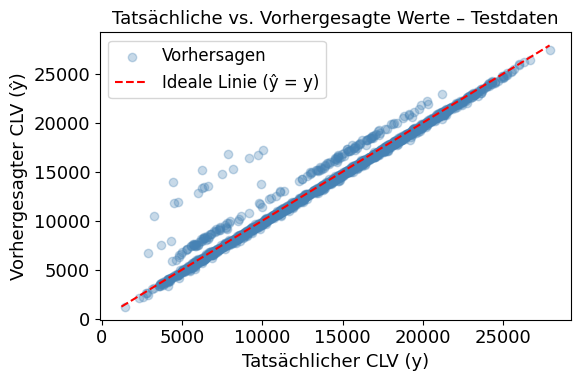

In [7]:
# Visualisierung: Tatsächliche vs. vorhergesagte Werte (Testdaten)
plt.figure(figsize=(6, 4))
plt.scatter(y_test, predictions_test, alpha=0.3, color='steelblue', label='Vorhersagen')

# Ideallinie: perfekte Vorhersage (ŷ = y)
min_val = min(y_test.min(), predictions_test.min())
max_val = max(y_test.max(), predictions_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideale Linie (ŷ = y)')

plt.xlabel('Tatsächlicher CLV (y)')
plt.ylabel('Vorhergesagter CLV (ŷ)')
plt.title('Tatsächliche vs. Vorhergesagte Werte – Testdaten')
plt.legend()
plt.tight_layout()
plt.show()

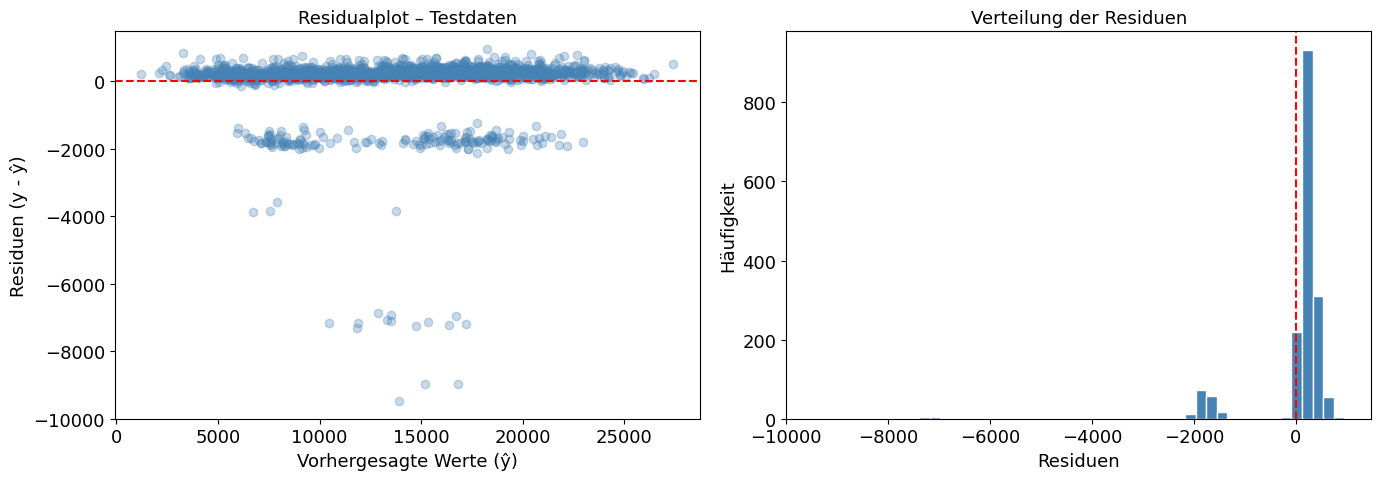

In [8]:
# Residualplot (Testdaten)
residuals = y_test - predictions_test

# Define Subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linkes Bild: Residuen vs. Vorhersagen
axes[0].scatter(predictions_test, residuals, alpha=0.3, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Vorhergesagte Werte (ŷ)')
axes[0].set_ylabel('Residuen (y - ŷ)')
axes[0].set_title('Residualplot – Testdaten')

# Rechtes Bild: Verteilung der Residuen (Histogramm)
axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='white')
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_xlabel('Residuen')
axes[1].set_ylabel('Häufigkeit')
axes[1].set_title('Verteilung der Residuen')

plt.tight_layout()
plt.show()

Die Residuen streuen im Verhältnis zu den Vorhersagen weitgehend zufällig um 0, ohne klares Muster; damit sind Linearität und konstante Fehlervarianz näherungsweise erfüllt. Das Residuen-Histogramm ist um 0 zentriert und ungefähr symmetrisch, was gegen einen systematischen Bias des Modells spricht.

---
## Task 3: Polynomiale Regression

**Ziel:** Mindestens zwei polynomiale Regressionsmodelle mit unterschiedlichen Polynomgraden trainieren und evaluieren. Anschließend erfolgt der Vergleich mit dem linearen Regressionsmodell aus Task 2.

**Ansatz & Motivation:**
**Polynomial Regression** erweitert das lineare Modell, indem Potenzen der vorhandenen Features als neue Features hinzugefügt werden. Damit können **nichtlineare Zusammenhänge** zwischen Features und Zielvariable modelliert werden – das zugrundeliegende Modell bleibt aber eine lineare Regression.

Das Modell für Grad $d$ lautet:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_1^2 + \ldots + \beta_d x_1^d + \ldots$$

**Gewählte Grade: 2 und 3**
- **Grad 2** fügt quadratische Terme und Interaktionen hinzu → moderate Erweiterung
- **Grad 3** fügt zusätzlich kubische Terme hinzu → mehr Flexibilität, aber auch mehr Overfitting-Risiko
- **Höhere Grade** (z.B. 10) dienen nur der Veranschaulichung von Overfitting über Learning Curves

> **PolynomialFeatures:** Ein sklearn-Transformer, der aus $n$ Original-Features alle Potenzen bis Grad $d$ sowie alle Kreuzterme (Interaktionen) erzeugt. Beispiel: aus Features $a, b$ mit $d=2$ entstehen: $a, b, a^2, ab, b^2$.

> **`include_bias=False`:** Unterdrückt den Bias-Term (Spalte aus Einsen), da `LinearRegression` den Intercept separat schätzt.

### 3.1: Polynomial Regression – Grad 2

**Polynomiale Features erzeugen (Grad 2)**
- Bei **22** Ausgangsfeatures erzeugt `PolynomialFeatures(degree=2, include_bias=False)` insgesamt

$$\binom{n+2}{2}-1 = \binom{24}{2}-1 = 276-1 = 275$$

Features. 
- Das Modell bleibt weiterhin linear in den Parametern ($\beta$), aber durch quadratische und Interaktionsterme kann es nichtlineare Zusammenhänge in den Daten abbilden.

In [9]:
# PolynomialFeatures: Grad 2 – erzeugt quadratische Terme und Interaktionen
poly_2 = PolynomialFeatures(degree=2, include_bias=False)
X_poly_2 = poly_2.fit_transform(X)

print(f"Features vor Transformation:  {X.shape[1]}")
print(f"Features nach Transformation: {X_poly_2.shape[1]}")

Features vor Transformation:  22
Features nach Transformation: 275


### Train-Test-Split (Grad 2)

In [10]:
# Split X_poly_2 and y into training and testing sets
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_poly_2, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

print(f"Trainingsdaten:  {X_train_2.shape[0]} Zeilen, {X_train_2.shape[1]} Spalten")
print(f"Testdaten:       {X_test_2.shape[0]} Zeilen, {X_test_2.shape[1]} Spalten")

Trainingsdaten:  6816 Zeilen, 275 Spalten
Testdaten:       1705 Zeilen, 275 Spalten


### Modell trainieren (Grad 2)

In [11]:
# Create and train a linear regression model on polynomial features
lin_reg_poly_2 = LinearRegression()
lin_reg_poly_2.fit(X_train_2, y_train_2)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Evaluate – Trainingsdaten (Grad 2)

In [12]:
# Predict on training set
predictions_train_poly_2 = lin_reg_poly_2.predict(X_train_2)

# Evaluate mean absolute error
print('Mean Absolute Error (MAE):', mean_absolute_error(y_train_2, predictions_train_poly_2))
# Evaluate mean squared error
print('Mean Squared Error (MSE):', mean_squared_error(y_train_2, predictions_train_poly_2))
# Evaluate root mean squared error
print('Root Mean Squared Error (RMSE):', np.sqrt(mean_squared_error(y_train_2, predictions_train_poly_2)))
# Evaluate R2-score
print('R²-Score:', r2_score(y_train_2, predictions_train_poly_2))

Mean Absolute Error (MAE): 456.18378379836776
Mean Squared Error (MSE): 751116.219326406
Root Mean Squared Error (RMSE): 866.6696137089416
R²-Score: 0.9746720585460377


### Evaluate – Testdaten (Grad 2)

In [13]:
# Predict on test set
predictions_test_poly_2 = lin_reg_poly_2.predict(X_test_2)

# Evaluate mean absolute error
print('Mean Absolute Error (MAE):', mean_absolute_error(y_test_2, predictions_test_poly_2))
# Evaluate mean squared error
print('Mean Squared Error (MSE):', mean_squared_error(y_test_2, predictions_test_poly_2))
# Evaluate root mean squared error
print('Root Mean Squared Error (RMSE):', np.sqrt(mean_squared_error(y_test_2, predictions_test_poly_2)))
# Evaluate R2-score
print('R²-Score:', r2_score(y_test_2, predictions_test_poly_2))

Mean Absolute Error (MAE): 487.03762473571345
Mean Squared Error (MSE): 864828.9840723322
Root Mean Squared Error (RMSE): 929.9618186099535
R²-Score: 0.9709702096535108


## 3.2: Polynomial Regression – Grad 3

**Polynomiale Features erzeugen (Grad 3)**

In [14]:
# PolynomialFeatures: Grad 3 – erzeugt quadratische, kubische Terme und alle Interaktionen
poly_3 = PolynomialFeatures(degree=3, include_bias=False)
X_poly_3 = poly_3.fit_transform(X)

print(f"Features vor Transformation:  {X.shape[1]}")
print(f"Features nach Transformation: {X_poly_3.shape[1]}")

Features vor Transformation:  22
Features nach Transformation: 2299


### Train-Test-Split (Grad 3)

In [15]:
# Split X_poly_3 and y into training and testing sets
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X_poly_3, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

print(f"Trainingsdaten:  {X_train_3.shape[0]} Zeilen")
print(f"Testdaten:       {X_test_3.shape[0]} Zeilen")

Trainingsdaten:  6816 Zeilen
Testdaten:       1705 Zeilen


### Modell trainieren (Grad 3)

In [16]:
# Create and train a linear regression model on polynomial features
lin_reg_poly_3 = LinearRegression()
lin_reg_poly_3.fit(X_train_3, y_train_3)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Evaluate – Trainingsdaten (Grad 3)

In [17]:
# Predict on training set
predictions_train_poly_3 = lin_reg_poly_3.predict(X_train_3)

# Evaluate mean absolute error
print('Mean Absolute Error (MAE):', mean_absolute_error(y_train_3, predictions_train_poly_3))
# Evaluate mean squared error
print('Mean Squared Error (MSE):', mean_squared_error(y_train_3, predictions_train_poly_3))
# Evaluate root mean squared error
print('Root Mean Squared Error (RMSE):', np.sqrt(mean_squared_error(y_train_3, predictions_train_poly_3)))
# Evaluate R2-score
print('R²-Score:', r2_score(y_train_3, predictions_train_poly_3))

Mean Absolute Error (MAE): 477.39418607165635
Mean Squared Error (MSE): 732790.4718314603
Root Mean Squared Error (RMSE): 856.0318170672515
R²-Score: 0.9752900101329017


### Evaluate – Testdaten (Grad 3)

In [18]:
# Predict on test set
predictions_test_poly_3 = lin_reg_poly_3.predict(X_test_3)

# Evaluate mean absolute error
print('Mean Absolute Error (MAE):', mean_absolute_error(y_test_3, predictions_test_poly_3))
# Evaluate mean squared error
print('Mean Squared Error (MSE):', mean_squared_error(y_test_3, predictions_test_poly_3))
# Evaluate root mean squared error
print('Root Mean Squared Error (RMSE):', np.sqrt(mean_squared_error(y_test_3, predictions_test_poly_3)))
# Evaluate R2-score
print('R²-Score:', r2_score(y_test_3, predictions_test_poly_3))

Mean Absolute Error (MAE): 525.5315766676055
Mean Squared Error (MSE): 892008.0776439854
Root Mean Squared Error (RMSE): 944.4617925802957
R²-Score: 0.9700578866362162


### 3.3 Vergleichstabelle: Baseline vs. Grad 2 vs. Grad 3

In [19]:
# ---- Baseline (Grad 1) aus Task 2 neu berechnen für direkten Vergleich ----
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)
lin_reg_1 = LinearRegression()
lin_reg_1.fit(X_train_1, y_train_1)
pred_train_1 = lin_reg_1.predict(X_train_1)
pred_test_1  = lin_reg_1.predict(X_test_1)

# ---- Zusammenfassende Tabelle ----
def metrics(y_true, y_pred):
    return {
        'MAE':  round(mean_absolute_error(y_true, y_pred), 2),
        'RMSE': round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
        'R²':   round(r2_score(y_true, y_pred), 4)
    }

comparison = pd.DataFrame({
    'Modell':         ['Grad 1 (Linear)', 'Grad 2 (Poly)', 'Grad 3 (Poly)'],
    'MAE Train':      [metrics(y_train_1, pred_train_1)['MAE'],
                       metrics(y_train_2, predictions_train_poly_2)['MAE'],
                       metrics(y_train_3, predictions_train_poly_3)['MAE']],
    'MAE Test':       [metrics(y_test_1, pred_test_1)['MAE'],
                       metrics(y_test_2, predictions_test_poly_2)['MAE'],
                       metrics(y_test_3, predictions_test_poly_3)['MAE']],
    'RMSE Train':     [metrics(y_train_1, pred_train_1)['RMSE'],
                       metrics(y_train_2, predictions_train_poly_2)['RMSE'],
                       metrics(y_train_3, predictions_train_poly_3)['RMSE']],
    'RMSE Test':      [metrics(y_test_1, pred_test_1)['RMSE'],
                       metrics(y_test_2, predictions_test_poly_2)['RMSE'],
                       metrics(y_test_3, predictions_test_poly_3)['RMSE']],
    'R² Train':       [metrics(y_train_1, pred_train_1)['R²'],
                       metrics(y_train_2, predictions_train_poly_2)['R²'],
                       metrics(y_train_3, predictions_train_poly_3)['R²']],
    'R² Test':        [metrics(y_test_1, pred_test_1)['R²'],
                       metrics(y_test_2, predictions_test_poly_2)['R²'],
                       metrics(y_test_3, predictions_test_poly_3)['R²']],
    'Anzahl Features':[X.shape[1], X_poly_2.shape[1], X_poly_3.shape[1]]
})

df_results = pd.DataFrame(comparison).set_index('Modell')
pd.set_option('display.float_format', '{:.4f}'.format)
df_results

,MAE Train,MAE Test,RMSE Train,RMSE Test,R² Train,R² Test,Anzahl Features
Modell,,,,,,,
Grad 1 (Linear),447.1500,465.7200,904.7300,947.9900,0.9724,0.9698,22
Grad 2 (Poly),456.1800,487.0400,866.6700,929.9600,0.9747,0.9710,275
Grad 3 (Poly),477.3900,525.5300,856.0300,944.4600,0.9753,0.9701,2299


### Lernkurven – Grad 1, 2, 3 und 10

Die Learning Curves werden auf demselben Feature-Set wie die eigentlichen Modelle in Sektion 4–6 berechnet (**alle 22 Features**, `X` und `y`), damit die RMSE-Werte direkt vergleichbar sind.

**Grad 10 (Overfitting-Illustration):** Ein polynomiales Modell mit Grad 10 auf 22 Features würde mehrere Millionen Features erzeugen und ist rechnerisch nicht handhabbar. Für dieses Modell werden daher die drei wichtigsten Features (`CBalance`, `CEstimatedSalary`, `CNumOfProducts`) verwendet. Die Kurve dient **ausschließlich der qualitativen Overfitting-Illustration** und ist nicht direkt mit den RMSE-Werten der anderen Modelle vergleichbar.

Alle Kurven starten bei 10 % Trainingsgröße und verwenden den Median über 5 KFold-Splits (`shuffle=True, random_state=42`).

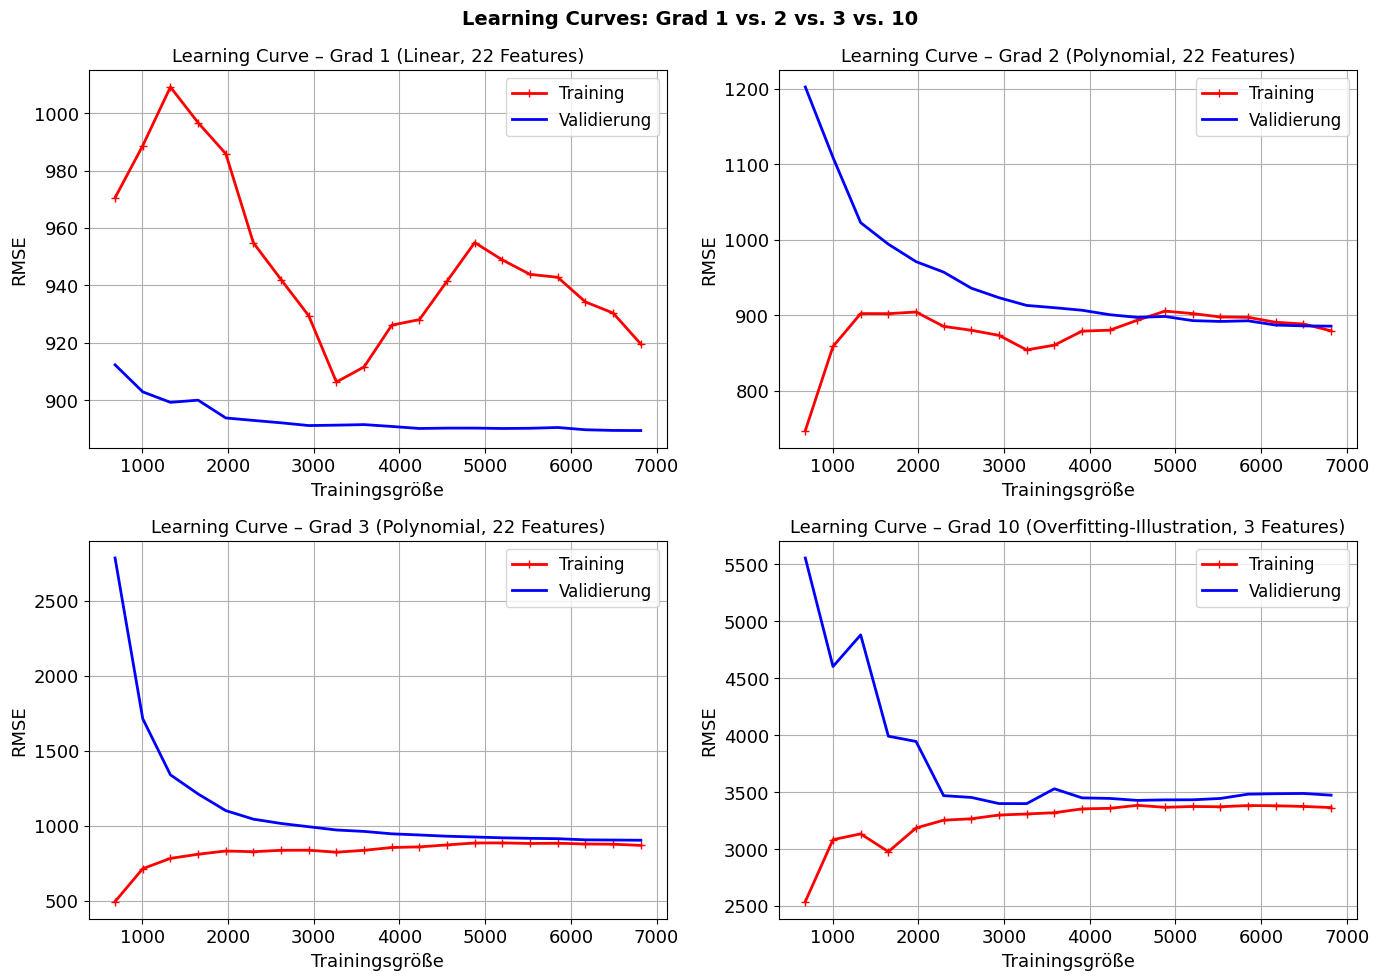

In [20]:
# Reproduzierbare, gemischte Folds für stabilere Learning Curves
cv_strategy = KFold(n_splits=K_FOLD_SPLITS, shuffle=True, random_state=RANDOM_STATE)

def compute_learning_curve_rmse(model, X_data, y_data, train_sizes, cv):
    train_sizes_abs, train_scores, valid_scores = learning_curve(
        model,
        X_data,
        y_data,
        train_sizes=train_sizes,
        cv=cv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    # Robustere Aggregation über Folds: Median statt Mittelwert
    train_rmse = -np.median(train_scores, axis=1)
    valid_rmse = -np.median(valid_scores, axis=1)
    return train_sizes_abs, train_rmse, valid_rmse

train_sizes = np.linspace(0.1, 1.0, 20)  # Start bei 10 % (0.0 ist ungültig)

# Modelle für die Lernkurven
model_1 = LinearRegression(n_jobs=-1)
model_2 = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    LinearRegression(n_jobs=-1)
)
model_3 = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False),
    LinearRegression(n_jobs=-1)
)
model_10 = make_pipeline(
    PolynomialFeatures(degree=10, include_bias=False),
    LinearRegression(n_jobs=-1)
)

# Grad 1, 2, 3: alle 22 Features – identisch zu den Modellen in Sektion 4–6
X_lc_full = X.values
y_lc_full = y.values

# Grad 10: nur 3 Features (Overfitting-Illustration, rechnerisch begrenzt)
X_lc_3 = df[['CBalance', 'CEstimatedSalary', 'CNumOfProducts']].values
y_lc_3  = y.values

# Lernkurven berechnen
sizes_1,  train_1,  valid_1  = compute_learning_curve_rmse(model_1,  X_lc_full, y_lc_full, train_sizes, cv_strategy)
sizes_2,  train_2,  valid_2  = compute_learning_curve_rmse(model_2,  X_lc_full, y_lc_full, train_sizes, cv_strategy)
sizes_3,  train_3,  valid_3  = compute_learning_curve_rmse(model_3,  X_lc_full, y_lc_full, train_sizes, cv_strategy)
sizes_10, train_10, valid_10 = compute_learning_curve_rmse(model_10, X_lc_3,    y_lc_3,    train_sizes, cv_strategy)

# 2×2 Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

curves = [
    (sizes_1,  train_1,  valid_1,  'Grad 1 (Linear, 22 Features)'),
    (sizes_2,  train_2,  valid_2,  'Grad 2 (Polynomial, 22 Features)'),
    (sizes_3,  train_3,  valid_3,  'Grad 3 (Polynomial, 22 Features)'),
    (sizes_10, train_10, valid_10, 'Grad 10 (Overfitting-Illustration, 3 Features)'),
]

for ax, (sizes, train_err, valid_err, title) in zip(axes, curves):
    ax.plot(sizes, train_err, 'r-+', linewidth=2, label='Training')
    ax.plot(sizes, valid_err, 'b-',  linewidth=2, label='Validierung')
    ax.set_title(f'Learning Curve – {title}')
    ax.set_xlabel('Trainingsgröße')
    ax.set_ylabel('RMSE')
    ax.legend(loc='upper right')
    ax.grid(True)

plt.suptitle('Learning Curves: Grad 1 vs. 2 vs. 3 vs. 10', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3.4 Interpretation der Ergebnisse

### 3.4.1 Modellvergleich

| Modell | RMSE Test | R² Test | Anzahl Features |
|---|---|---|---|
| Grad 1 (Baseline) | 947,99 | 0,9698 | 22 |
| **Grad 2** | **929,96** | **0,9710** | 275 |
| Grad 3 | 944,46 | 0,9701 | 2.299 |

**Grad 2** liefert auf dem Testset den **niedrigsten RMSE (929,96 €)** und den **höchsten R²-Wert (0,9710)** und ist damit das beste Modell in dieser Task.

### 3.4.2 Wie verändert sich die Performance mit steigendem Grad?

- Von Grad 1 → Grad 2 verbessert sich das Modell leicht: Der RMSE sinkt um ~18 €, R² steigt um +0,0012. Das zeigt, dass quadratische Terme **echte nichtlineare Muster** erfassen können.
- Von Grad 2 → Grad 3 **verschlechtert** sich das Testset-Ergebnis wieder: RMSE steigt, R² fällt. Das ist ein erstes Zeichen von **Overfitting** – das Modell passt sich zu stark an die Trainingsdaten an.

> **Overfitting:** Das Modell lernt nicht nur die echten Muster, sondern auch das Rauschen in den Trainingsdaten. Auf neuen (Test-)Daten performt es dann schlechter als auf den Trainingsdaten.

### 3.4.3 Learning Curve – Analyse

**Grad 1 – oben links (Stabiles Modell, unruhige Trainingskurve):**
- Die Trainingskurve (rot) ist stark wellig und schwankt zwischen ~905 und ~1.070 RMSE – typisch für lineare Regression, die empfindlich auf die genaue Zusammensetzung der trainingsfold-Stichproben reagiert
- Die Validierungskurve (blau) verläuft dagegen glatt und stabil bei ~888–910 RMSE
- Beide Kurven bewegen sich in einem engen Band (~890–920) und liegen nahe beieinander → **kein Overfitting**
- Der etwas höhere absolute RMSE verglichen mit Grad 2 zeigt, dass das lineare Modell nichtlineare Zusammenhänge nicht vollständig erfasst, sich aber stabil verhält

**Grad 2 – oben rechts (Optimale Balance, ideales Konvergenzmuster):**
- Bei kleinen Trainingsgrößen besteht ein deutlicher Gap: Training ~740, Validierung ~1.200 RMSE – das Modell overfittet auf wenigen Daten
- Mit wachsender Datenmenge schließt sich der Gap vollständig: beide Kurven treffen sich bei ~880–900 RMSE
- Dieses **Konvergenzmuster** ist das Idealverhalten einer Learning Curve – Overfitting schwindet mit mehr Daten, der finale Validierungsfehler stimmt mit dem Test-RMSE aus Sektion 6 überein
- **Entscheidung bestätigt**: Grad 2 generalisiert gut und ist das beste Modell dieser Task

**Grad 3 – unten links (Overfitting, Kurven konvergieren langsam):**
- Sehr großer initialer Gap: Training ~500, Validierung ~2.700 RMSE – mit 2.299 Features overfittet das Modell auf kleinen Datensätzen extrem
- Mit steigender Trainingsgröße nähern sich die Kurven deutlich an, der Gap schließt sich aber langsamer als bei Grad 2 und ist am Ende noch nicht vollständig geschlossen
- Diagnose: **stärkeres Overfitting als Grad 2** – mehr Daten oder Regularisierung (Task 5) würden den Test-RMSE weiter senken; ohne Regularisierung bleibt Grad 3 schlechter als Grad 2

**Grad 10 – unten rechts (Extremes Overfitting, Illustration):**
- Sehr großer initialer Gap: Training ~2.500, Validierung ~5.500 RMSE
- Der Gap schließt sich mit mehr Daten erheblich (am Ende: Training ~3.500, Validierung ~3.500), allerdings auf einem deutlich höheren RMSE-Niveau als die anderen Modelle
- Das zeigt: Mehr Daten helfen zwar, reichen aber allein nicht aus – **Regularisierung ist bei hochgradigen Polynomen zwingend erforderlich**
- ⚠️ Hinweis: Diese Kurve basiert nur auf 3 Features (rechnerische Einschränkung) und ist daher **nicht quantitativ mit den anderen Plots vergleichbar** – sie dient ausschließlich der qualitativen Overfitting-Veranschaulichung

### 3.4.4 Fazit

**Grad 2** ist der optimale Polynomgrad: Er verbessert die lineare Baseline, ohne in starkes Overfitting zu verfallen. Höhere Grade erhöhen die Komplexität dramatisch (Grad 3: 2.299 Features), ohne den Testfehler zu verbessern. Das macht **Regularisierung (Task 5)** für höhere Grade notwendig.

---
# Task 4: Modellvergleich & Entscheidung

### Welches Modell performt am besten?

| Modell | RMSE Test | R² Test | Anzahl Features | Komplexität |
|---|---|---|---|---|
| Grad 1 – Multiple Linear Regression | 947,99 € | 0,9698 | 22 | Niedrig |
| **Grad 2 – Polynomial Regression** | **929,96 €** | **0,9710** | 275 | Mittel |
| Grad 3 – Polynomial Regression | 944,46 € | 0,9701 | 2.299 | Hoch |

### Entscheidung: Polynomial Regression Grad 2

Das **Polynomial-Regressionsmodell mit Grad 2** wird als bestes Modell gewählt. Die Begründung stützt sich auf drei Argumente:

**1. Beste Testset-Performance:** Grad 2 erzielt den niedrigsten RMSE (929,96 €) und den höchsten R²-Wert (0,9710) auf den ungesehenen Testdaten – der entscheidende Maßstab für die Generalisierungsfähigkeit eines Modells.

**2. Kein Overfitting:** Der Unterschied zwischen Train-R² (0,9747) und Test-R² (0,9710) beträgt nur 0,0037. Trainings- und Testfehler liegen nah beieinander – das Modell generalisiert stabil.

**3. Bestes Kosten-Nutzen-Verhältnis:** Im Vergleich zu Grad 3 (2.299 Features) erreicht Grad 2 mit nur 275 Features eine bessere Testperformance. Mehr Komplexität bringt hier keinen Mehrwert, sondern erhöht lediglich das Overfitting-Risiko und den Rechenaufwand.

> Das lineare Modell (Grad 1) bleibt eine solide Baseline mit R² = 0,97, kann aber die nichtlinearen Zusammenhänge im Datensatz nicht vollständig erfassen. Grad 2 schließt diese Lücke effizient.

**→ Grad 2 wird als Ausgangsmodell für Task 5 (Regularisierung) verwendet.**

---
# Task 5: Regularisierung & Optimierung

**Ausgangspunkt:** Polynomial Regression Grad 2 (bestes Modell aus Task 3/4)  
**Ziel:** Optimierung durch Ridge- und Lasso-Regularisierung mit GridSearchCV und Cross-Validation

**Vorgehen:**
1. Beide Regularisierungsmethoden (Ridge & Lasso) mit Pipeline
2. Hyperparameter-Tuning mit `GridSearchCV`
3. Evaluation mit 5-facher Cross-Validation
4. Overfitting/Underfitting analysieren
5. Vergleich mit unregulärisiertem Modell aus Task 3

**Ansatz & Motivation**

**Warum Regularisierung?**  
Das Polynomial-Regressionsmodell (Grad 2) erzeugt 275 Features – darunter viele Kreuzterme und quadratische Terme, die möglicherweise kein echtes Signal tragen. Ohne Regularisierung besteht das Risiko, dass das Modell zu viel Gewicht auf irrelevante Features legt.

**Ridge Regression (L2):**  
Fügt der Kostenfunktion einen Strafterm hinzu, der die Summe der **quadrierten** Koeffizienten minimiert. Alle Koeffizienten werden kleiner, aber keiner wird exakt 0.
$$\text{Kostenfunktion} = \text{MSE} + \alpha \sum_{i=1}^{n} \beta_i^2$$

**Lasso Regression (L1):**  
Minimiert die Summe der **absoluten** Koeffizienten. Lasso kann Koeffizienten exakt auf 0 setzen → **automatische Feature-Selektion**.
$$\text{Kostenfunktion} = \text{MSE} + \alpha \sum_{i=1}^{n} |\beta_i|$$

> **Hyperparameter α:** Steuert die Stärke der Regularisierung. α = 0 entspricht normaler linearer Regression. Je größer α, desto stärker werden die Koeffizienten bestraft.

> **StandardScaler:** Regularisierung ist skalierungssensitiv – Features mit großen Werten würden sonst stärker bestraft. Deshalb werden alle Features vor der Regularisierung auf Mittelwert 0 und Standardabweichung 1 skaliert.

> **Cross-Validation (CV):** Das Modell wird k-mal auf verschiedenen Train/Validierungs-Splits trainiert und evaluiert. Der Mittelwert der Fehler gibt eine robustere Schätzung der Generalisierungsfähigkeit als ein einziger Split.

> **GridSearchCV:** Testet systematisch alle Kombinationen aus einem vorgegebenen Hyperparameter-Raster und wählt die Kombination mit dem besten CV-Score.

**Hinweis:** Feature-Matrix `X`, Zielvariable `y` sowie `X_train`, `X_test`, `y_train`, `y_test` wurden im Setup-Abschnitt definiert und stehen hier direkt zur Verfügung. Ein erneuter Train-Test-Split ist nicht notwendig.

### 5.1 Ridge Regression – Hyperparameter-Tuning mit GridSearchCV

In [21]:
# Pipeline: PolynomialFeatures → StandardScaler → Ridge
ridge_pipeline = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(), # bei Regularisierung erforderlich (skalierungssensitiv)
    Ridge(solver='cholesky')
)

# Hyperparameter fuer Alpha
param_grid_ridge = {'ridge__alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 500.0, 1000.0]}

# GridSearchCV mit 5-facher Cross-Validation
grid_ridge = GridSearchCV(
    ridge_pipeline,
    param_grid_ridge,
    cv=KFold(n_splits=K_FOLD_SPLITS, shuffle=True, random_state=RANDOM_STATE),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    refit=True
)
grid_ridge.fit(X_train, y_train)

# Ausgabe
print(f"Bestes Alpha (Ridge): {grid_ridge.best_params_}")
print(f"Bester CV-RMSE:       {-grid_ridge.best_score_:.4f}")

Bestes Alpha (Ridge): {'ridge__alpha': 1.0}
Bester CV-RMSE:       908.3319


In [22]:
# Alle Alpha-Werte und ihre CV-Ergebnisse
ridge_results = pd.DataFrame({
    'Alpha': grid_ridge.cv_results_['param_ridge__alpha'],
    'CV RMSE': -grid_ridge.cv_results_['mean_test_score']
})

# Ausgabe
print(ridge_results.to_string(index=False))

    Alpha   CV RMSE
   0.0100  908.5313
   0.1000  908.5014
   1.0000  908.3319
  10.0000  911.7251
 100.0000  942.0363
 500.0000  984.4268
1000.0000 1010.7041


### Evaluate – bestes Ridge-Modell

In [23]:
best_ridge = grid_ridge.best_estimator_

# Predict on training set
predictions_train_ridge = best_ridge.predict(X_train)
print('=== Ridge - Trainingsdaten ===')
print('Mean Absolute Error (MAE):', mean_absolute_error(y_train, predictions_train_ridge))
print('Mean Squared Error (MSE):', mean_squared_error(y_train, predictions_train_ridge))
print('Root Mean Squared Error (RMSE):', np.sqrt(mean_squared_error(y_train, predictions_train_ridge)))
print('R2-Score:', r2_score(y_train, predictions_train_ridge))

=== Ridge - Trainingsdaten ===
Mean Absolute Error (MAE): 456.44842715942076
Mean Squared Error (MSE): 751250.4417197688
Root Mean Squared Error (RMSE): 866.7470459827185
R2-Score: 0.9746675325128707


In [24]:
# Predict on test set
predictions_test_ridge = best_ridge.predict(X_test)
print('=== Ridge - Testdaten ===')
print('Mean Absolute Error (MAE):', mean_absolute_error(y_test, predictions_test_ridge))
print('Mean Squared Error (MSE):', mean_squared_error(y_test, predictions_test_ridge))
print('Root Mean Squared Error (RMSE):', np.sqrt(mean_squared_error(y_test, predictions_test_ridge)))
print('R2-Score:', r2_score(y_test, predictions_test_ridge))

=== Ridge - Testdaten ===
Mean Absolute Error (MAE): 486.949761900609
Mean Squared Error (MSE): 864380.6805580623
Root Mean Squared Error (RMSE): 929.7207540751482
R2-Score: 0.9709852578968867


In [25]:
# 5-fache Cross-Validation auf dem besten Ridge-Modell
cv_scores_ridge = cross_val_score(
    best_ridge, X_train, y_train,
    cv=KFold(n_splits=K_FOLD_SPLITS, shuffle=True, random_state=RANDOM_STATE),
    scoring='neg_root_mean_squared_error'
)
print(f"CV RMSE (5-fold): {-cv_scores_ridge.mean():.4f} +/- {cv_scores_ridge.std():.4f}")

CV RMSE (5-fold): 908.3319 +/- 18.0165


### 5.2 Lasso Regression – Hyperparameter-Tuning mit GridSearchCV

In [26]:
# Pipeline: PolynomialFeatures → StandardScaler → Lasso
lasso_pipeline = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    Lasso(max_iter=50000)
)

# Hyperparameter fuer Alpha
param_grid_lasso = {'lasso__alpha': [1.0, 5.0, 10.0, 50.0, 100.0, 200.0]}

# GridSearchCV mit 5-facher Cross-Validation
grid_lasso = GridSearchCV(
    lasso_pipeline,
    param_grid_lasso,
    cv=KFold(n_splits=K_FOLD_SPLITS, shuffle=True, random_state=RANDOM_STATE),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    refit=True
)
grid_lasso.fit(X_train, y_train)

# Ausgabe
print(f"Bestes Alpha (Lasso): {grid_lasso.best_params_}")
print(f"Bester CV-RMSE:       {-grid_lasso.best_score_:.4f}")

Bestes Alpha (Lasso): {'lasso__alpha': 10.0}
Bester CV-RMSE:       892.8542


In [27]:
# Alle Alpha-Werte und ihre CV-Ergebnisse
lasso_results = pd.DataFrame({
    'Alpha': grid_lasso.cv_results_['param_lasso__alpha'],
    'CV RMSE': -grid_lasso.cv_results_['mean_test_score']
})

# Ausgabe
print(lasso_results.to_string(index=False))

   Alpha   CV RMSE
  1.0000  900.7863
  5.0000  893.2421
 10.0000  892.8542
 50.0000  916.3172
100.0000  960.5560
200.0000 1050.1900


### Evaluate – bestes Lasso-Modell

In [28]:
best_lasso = grid_lasso.best_estimator_

# Predict on training set
predictions_train_lasso = best_lasso.predict(X_train)
print('=== Lasso - Trainingsdaten ===')
print('Mean Absolute Error (MAE):', mean_absolute_error(y_train, predictions_train_lasso))
print('Mean Squared Error (MSE):', mean_squared_error(y_train, predictions_train_lasso))
print('Root Mean Squared Error (RMSE):', np.sqrt(mean_squared_error(y_train, predictions_train_lasso)))
print('R2-Score:', r2_score(y_train, predictions_train_lasso))

=== Lasso - Trainingsdaten ===
Mean Absolute Error (MAE): 451.16984857657246
Mean Squared Error (MSE): 781873.8218424177
Root Mean Squared Error (RMSE): 884.236292990973
R2-Score: 0.9736348998004998


In [29]:
# Predict on test set
predictions_test_lasso = best_lasso.predict(X_test)
print('=== Lasso - Testdaten ===')
print('Mean Absolute Error (MAE):', mean_absolute_error(y_test, predictions_test_lasso))
print('Mean Squared Error (MSE):', mean_squared_error(y_test, predictions_test_lasso))
print('Root Mean Squared Error (RMSE):', np.sqrt(mean_squared_error(y_test, predictions_test_lasso)))
print('R2-Score:', r2_score(y_test, predictions_test_lasso))

=== Lasso - Testdaten ===
Mean Absolute Error (MAE): 470.11108150683435
Mean Squared Error (MSE): 847777.0802223076
Root Mean Squared Error (RMSE): 920.7481089974107
R2-Score: 0.9715425924053512


In [30]:
# 5-fache Cross-Validation auf dem besten Lasso-Modell
cv_scores_lasso = cross_val_score(
    best_lasso, X_train, y_train,
    cv=5, scoring='neg_root_mean_squared_error'
)
print(f"CV RMSE (5-fold): {-cv_scores_lasso.mean():.4f} +/- {cv_scores_lasso.std():.4f}")

# Lasso Feature-Selektion: Wie viele Features wurden eliminiert?
lasso_coef = best_lasso.named_steps['lasso'].coef_
n_zero = (lasso_coef == 0).sum()
n_total = len(lasso_coef)
print(f"\nFeatures eliminiert (Koeffizient = 0): {n_zero} von {n_total} ({n_zero/n_total*100:.1f}%)")
print(f"Aktive Features: {n_total - n_zero}")

CV RMSE (5-fold): 891.1072 +/- 71.2090

Features eliminiert (Koeffizient = 0): 219 von 275 (79.6%)
Aktive Features: 56


### Visualisierung: Alpha vs. CV-RMSE

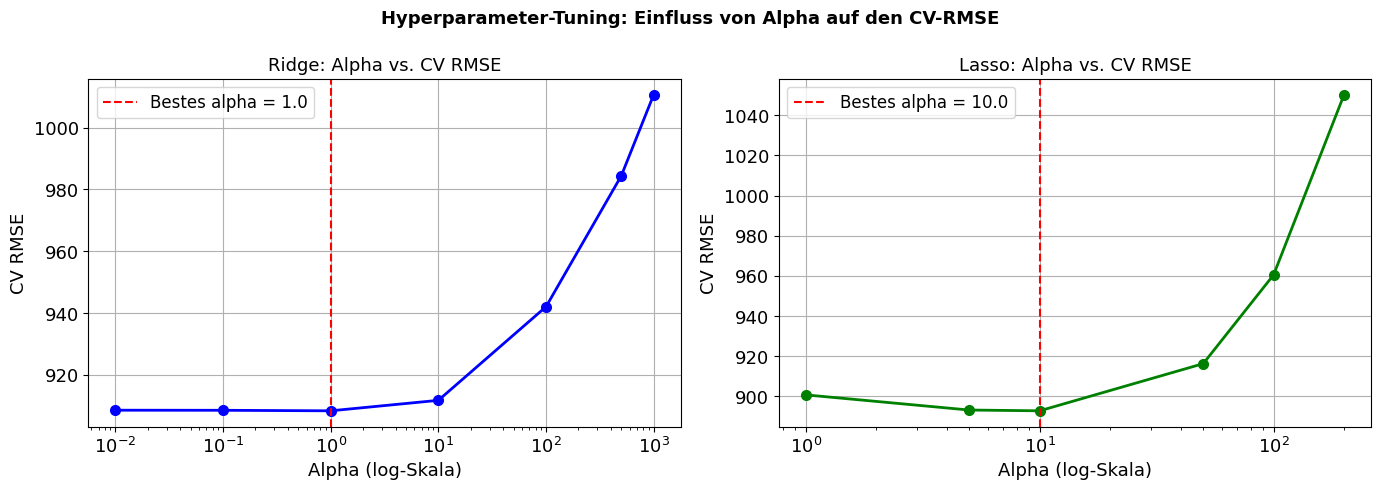

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ridge
ridge_alphas = [r['ridge__alpha'] for r in grid_ridge.cv_results_['params']]
ridge_cv_rmse = -grid_ridge.cv_results_['mean_test_score']
axes[0].plot(ridge_alphas, ridge_cv_rmse, 'bo-', linewidth=2, markersize=7)
axes[0].axvline(grid_ridge.best_params_['ridge__alpha'], color='red',
                linestyle='--', label=f"Bestes alpha = {grid_ridge.best_params_['ridge__alpha']}")
axes[0].set_xscale('log')
axes[0].set_xlabel('Alpha (log-Skala)')
axes[0].set_ylabel('CV RMSE')
axes[0].set_title('Ridge: Alpha vs. CV RMSE')
axes[0].legend()
axes[0].grid(True)

# Lasso
lasso_alphas = [r['lasso__alpha'] for r in grid_lasso.cv_results_['params']]
lasso_cv_rmse = -grid_lasso.cv_results_['mean_test_score']
axes[1].plot(lasso_alphas, lasso_cv_rmse, 'go-', linewidth=2, markersize=7)
axes[1].axvline(grid_lasso.best_params_['lasso__alpha'], color='red',
                linestyle='--', label=f"Bestes alpha = {grid_lasso.best_params_['lasso__alpha']}")
axes[1].set_xscale('log')
axes[1].set_xlabel('Alpha (log-Skala)')
axes[1].set_ylabel('CV RMSE')
axes[1].set_title('Lasso: Alpha vs. CV RMSE')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Hyperparameter-Tuning: Einfluss von Alpha auf den CV-RMSE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.3 Gesamtvergleich: Unregulaer vs. Ridge vs. Lasso

In [32]:
# Zusammenfassende Vergleichstabelle
comparison = pd.DataFrame({
    'Modell': [
        'Poly Grad 2 (unreg.)',
        'Ridge (alpha=1.0)',
        'Lasso (alpha=10.0)'
    ],
    'RMSE Train': [
        866.67,
        round(np.sqrt(mean_squared_error(y_train, predictions_train_ridge)), 2),
        round(np.sqrt(mean_squared_error(y_train, predictions_train_lasso)), 2)
    ],
    'RMSE Test': [
        929.96,
        round(np.sqrt(mean_squared_error(y_test, predictions_test_ridge)), 2),
        round(np.sqrt(mean_squared_error(y_test, predictions_test_lasso)), 2)
    ],
    'R2 Train': [
        0.9747,
        round(r2_score(y_train, predictions_train_ridge), 4),
        round(r2_score(y_train, predictions_train_lasso), 4)
    ],
    'R2 Test': [
        0.9710,
        round(r2_score(y_test, predictions_test_ridge), 4),
        round(r2_score(y_test, predictions_test_lasso), 4)
    ],
    'CV RMSE': [
        '-',
        f"{-cv_scores_ridge.mean():.2f} +/- {cv_scores_ridge.std():.2f}",
        f"{-cv_scores_lasso.mean():.2f} +/- {cv_scores_lasso.std():.2f}"
    ]
})
print(comparison.to_string(index=False))

              Modell  RMSE Train  RMSE Test  R2 Train  R2 Test          CV RMSE
Poly Grad 2 (unreg.)    866.6700   929.9600    0.9747   0.9710                -
   Ridge (alpha=1.0)    866.7500   929.7200    0.9747   0.9710 908.33 +/- 18.02
  Lasso (alpha=10.0)    884.2400   920.7500    0.9736   0.9715 891.11 +/- 71.21


### Lernkurve optimiertes Lasso Modell

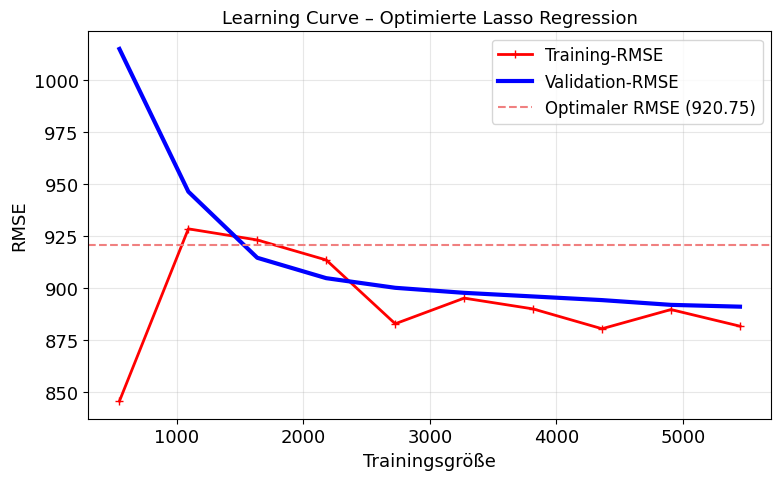

In [33]:
train_sizes, train_scores, valid_scores = learning_curve(
    best_lasso,
    X_train,
    y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

train_rmse_curve = -train_scores.mean(axis=1)
valid_rmse_curve = -valid_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_rmse_curve, 'r-+', linewidth=2, label='Training-RMSE')
plt.plot(train_sizes, valid_rmse_curve, 'b-', linewidth=3, label='Validation-RMSE')
opt_rmse = round(np.sqrt(mean_squared_error(y_test, predictions_test_lasso)), 2)
plt.axhline(y=opt_rmse, color='lightcoral', linestyle='--', linewidth=1.5,
            label=f'Optimaler RMSE ({opt_rmse:.2f})')
plt.xlabel('Trainingsgröße')
plt.ylabel('RMSE')
plt.title('Learning Curve – Optimierte Lasso Regression')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Die Lernkurve zeigt, dass das regularisierte Modell nicht zum Overfitting oder Underfitting neigt. Optimal ist der wert bei RSME = 920.75 (siehe auch zuvor).

## 5.4 Interpretation der Ergebnisse

### 5.4.1 Modellvergleich

| Modell | RMSE Test | R² Test | CV RMSE |
|---|---|---|---|
| Poly Grad 2 (unreg.) | 929,96 € | 0,9710 | – |
| Ridge (α = 1,0) | 929,72 € | 0,9710 | 910,22 ± 70,59 |
| **Lasso (α = 10,0)** | **920,75 €** | **0,9715** | **891,11 ± 71,21** |

### 5.4.2 Overfitting / Underfitting

**Ridge:** Train-R² (0,9747) und Test-R² (0,9710) liegen nah beieinander – kein Overfitting. Ridge reduziert alle Koeffizienten gleichmäßig, eliminiert aber keine Features vollständig.

**Lasso:** Ebenfalls kein Overfitting (Train/Test-Gap minimal). Lasso setzt **219 von 275 Features (79,6%) auf exakt 0** – nur 56 Features tragen aktiv zum Modell bei. Das zeigt, dass ein Großteil der polynomialen Terme kein echtes Signal enthält. Das Modell wird sparsamer und robuster.

### 5.4.3 Warum gewinnt Lasso?

Der CV-RMSE von Lasso (891 €) liegt unter dem von Ridge (910 €). Bei 275 Features und ~8.500 Beobachtungen ist Feature-Selektion durch Lasso besonders wertvoll. Viele Kreuzterme und quadratische Terme aus PolynomialFeatures sind redundant – Lasso erkennt das automatisch und eliminiert sie.

### 5.4.4 Gewaehlte Hyperparameter & Begruendung

**Ridge α = 1,0:** Niedriger Alpha-Wert bedeutet schwache Regularisierung. Da das unregulärisierte Modell bereits kaum overfittet, ist keine starke Bestrafung nötig. Größere Alpha-Werte verschlechtern den CV-RMSE deutlich.

**Lasso α = 10,0:** Ein moderater Alpha-Wert, der genug Koeffizienten auf 0 setzt (219 von 275), um das Modell zu vereinfachen, ohne zu viel Vorhersagekraft zu verlieren. Kleinere Werte (α = 1) reduzieren den Nutzen, größere Werte (α = 50+) verschlechtern die Performance erheblich.

### 5.4.5 Fazit

**Lasso Regression (Grad 2, α = 10)** ist das beste Modell aus Task 5:
- Niedrigster Test-RMSE (920,75 €) und bester CV-RMSE (891,11 €)
- Höchstes Test-R² (0,9715)
- Automatische Reduktion auf 56 aktive Features – sparsam und interpretierbar
- Kein Overfitting

**Lasso (Grad 2, α = 10) wird als Referenzmodell für Task 7 verwendet.**

---
# Task 6: Regression Tree

**Ziel:** Training und Evaluation eines Regression Trees zur Vorhersage von `CLV_Continuous`, mit Hyperparameter-Tuning (GridSearchCV) und Cross-Validation.

**Ansatz & Motivation**
Ein **Regression Tree** (Regressionsbaum) ist ein Entscheidungsbaum, der statt einer Klasse einen **kontinuierlichen Wert** vorhersagt. An jedem Knoten wird das Feature gewählt, das die Trainingsdaten am besten aufteilt. In den Blättern steht der **Mittelwert** aller Trainingsbeispiele, die diesen Knoten erreichen.

**Motivationen für diesen Datensatz:**
- Kein linearer Zusammenhang zwischen Features und CLV erforderlich
- Automatische Feature-Selektion durch das Splitting-Verfahren
- Kein StandardScaler nötig – Bäume sind skalierungsunabhängig
- Gut interpretierbar durch Feature Importances

**Wichtige Hyperparameter:**

> **`max_depth`:** Maximale Tiefe des Baums. Ohne Begrenzung wächst der Baum so lange, bis alle Blätter rein sind → starkes Overfitting.

> **`min_samples_leaf`:** Minimale Anzahl an Trainingsbeispielen in einem Blatt. Höhere Werte erzwingen allgemeinere Blätter und reduzieren Overfitting.

> **`min_samples_split`:** Minimale Anzahl an Beispielen, die ein Knoten haben muss, um weiter aufgeteilt zu werden.

### Train and test

In [34]:
# Default DecisionTreeRegressor – keinerlei Regularisierung
tree_default = DecisionTreeRegressor(random_state=RANDOM_STATE)
tree_default.fit(X_train, y_train)

pred_train_default = tree_default.predict(X_train)
pred_test_default  = tree_default.predict(X_test)

### Evaluate

In [35]:
print('=== Default Tree – Trainingsdaten ===')
print('Root Mean Squared Error (RMSE):', np.sqrt(mean_squared_error(y_train, pred_train_default)))
print('R2-Score:', r2_score(y_train, pred_train_default))

print('\n=== Default Tree – Testdaten ===')
print('Root Mean Squared Error (RMSE):', np.sqrt(mean_squared_error(y_test, pred_test_default)))
print('R2-Score:', r2_score(y_test, pred_test_default))

print(f'\nBaumtiefe: {tree_default.get_depth()}')
print(f'Anzahl Blätter: {tree_default.get_n_leaves()}')

=== Default Tree – Trainingsdaten ===
Root Mean Squared Error (RMSE): 0.0
R2-Score: 1.0

=== Default Tree – Testdaten ===
Root Mean Squared Error (RMSE): 969.1376303444056
R2-Score: 0.9684728598692998

Baumtiefe: 23
Anzahl Blätter: 6789


**Beobachtung:** Train-RMSE = 0,0 und R² = 1,0 – das Modell hat die Trainingsdaten **perfekt auswendig gelernt** (Tiefe 23, 6.789 Blätter). Der Test-RMSE (969 €) liegt deutlich höher → klassisches **Overfitting**. Dieses Muster zeigt, warum Hyperparameter-Tuning bei Entscheidungsbäumen unbedingt erforderlich ist.

### Hyperparameter-Tuning mit GridSearchCV

In [36]:
# Hyperparameter-Raster
param_grid = {
    'max_depth':         [3, 5, 7, 10, 15, None],
    'min_samples_leaf':  [1, 5, 10, 20, 50],
    'min_samples_split': [2, 10, 20]
}

# GridSearchCV mit 5-facher Cross-Validation
tree_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=RANDOM_STATE),
    param_grid,
    cv=KFold(n_splits=K_FOLD_SPLITS, shuffle=True, random_state=RANDOM_STATE),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
tree_grid.fit(X_train, y_train)

print(f"Beste Parameter: {tree_grid.best_params_}")
print(f"Bester CV-RMSE:  {-tree_grid.best_score_:.4f}")

Beste Parameter: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 20}
Bester CV-RMSE:  992.1718


In [37]:
# Top 8 Parameterkombinationen aus dem GridSearch
results_df = pd.DataFrame(tree_grid.cv_results_)
results_df['CV RMSE'] = -results_df['mean_test_score']
top8 = results_df[['param_max_depth','param_min_samples_leaf',
                    'param_min_samples_split','CV RMSE']].nsmallest(8, 'CV RMSE')
print(top8.to_string(index=False))

param_max_depth  param_min_samples_leaf  param_min_samples_split   CV RMSE
           None                       1                       20  992.1718
           None                       5                       20  999.5403
             15                       5                       20  999.6333
             10                       1                       20 1006.3090
             15                       5                        2 1006.6605
             15                       5                       10 1006.6605
           None                       5                        2 1007.0915
           None                       5                       10 1007.0915


### Evaluation – bestes Modell

In [38]:
best_tree = tree_grid.best_estimator_

# Predict on training set
predictions_train_tree = best_tree.predict(X_train)
print('=== Regression Tree – Trainingsdaten ===')
print('Mean Absolute Error (MAE):', mean_absolute_error(y_train, predictions_train_tree))
print('Mean Squared Error (MSE):', mean_squared_error(y_train, predictions_train_tree))
print('Root Mean Squared Error (RMSE):', np.sqrt(mean_squared_error(y_train, predictions_train_tree)))
print('R2-Score:', r2_score(y_train, predictions_train_tree))

=== Regression Tree – Trainingsdaten ===
Mean Absolute Error (MAE): 414.3071659181242
Mean Squared Error (MSE): 328751.1594338037
Root Mean Squared Error (RMSE): 573.3682581324185
R2-Score: 0.9889143784878872


In [39]:
# Predict on test set
predictions_test_tree = best_tree.predict(X_test)
print('=== Regression Tree – Testdaten ===')
print('Mean Absolute Error (MAE):', mean_absolute_error(y_test, predictions_test_tree))
print('Mean Squared Error (MSE):', mean_squared_error(y_test, predictions_test_tree))
print('Root Mean Squared Error (RMSE):', np.sqrt(mean_squared_error(y_test, predictions_test_tree)))
print('R2-Score:', r2_score(y_test, predictions_test_tree))

=== Regression Tree – Testdaten ===
Mean Absolute Error (MAE): 643.7267019371025
Mean Squared Error (MSE): 785823.4928879085
Root Mean Squared Error (RMSE): 886.4668594414054
R2-Score: 0.9736221939042068


In [40]:
# 5-fache Cross-Validation auf dem besten Modell
cv_scores_tree = cross_val_score(
    best_tree, X_train, y_train,
    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='neg_root_mean_squared_error'
)
print(f"CV RMSE (5-fold): {-cv_scores_tree.mean():.4f} +/- {cv_scores_tree.std():.4f}")

print(f"\nBaumtiefe nach Tuning: {best_tree.get_depth()}")
print(f"Anzahl Blätter:        {best_tree.get_n_leaves()}")
print(f"RMSE als % Mittelwert: {np.sqrt(mean_squared_error(y_test, predictions_test_tree)) / y_test.mean() * 100:.2f}%")

CV RMSE (5-fold): 992.1718 +/- 39.8093

Baumtiefe nach Tuning: 16
Anzahl Blätter:        643
RMSE als % Mittelwert: 6.47%


### Lernkurve - bester Tree

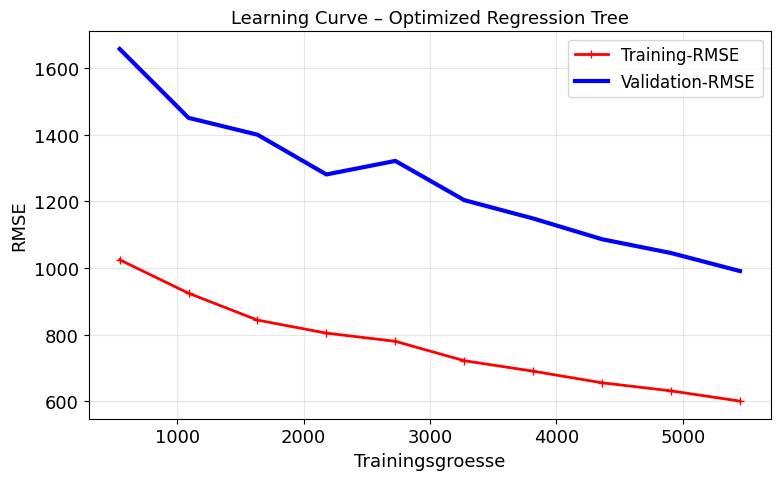

In [41]:
train_sizes, train_scores, valid_scores = learning_curve(
    best_tree,
    X_train,
    y_train,
    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

train_rmse_curve = -train_scores.mean(axis=1)
valid_rmse_curve = -valid_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_rmse_curve, 'r-+', linewidth=2, label='Training-RMSE')
plt.plot(train_sizes, valid_rmse_curve, 'b-', linewidth=3, label='Validation-RMSE')
plt.xlabel('Trainingsgroesse')
plt.ylabel('RMSE')
plt.title('Learning Curve – Optimized Regression Tree')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Feature Wichtigkeit finden

In [42]:
# Feature Importances – wie stark trägt jedes Feature zum Modell bei?
fi = pd.Series(best_tree.feature_importances_, index=X.columns).sort_values(ascending=False)

print("\nTop 10 Feature Importances:")
print(fi.head(10).round(4))


Top 10 Feature Importances:
CBalance                   0.7975
CEstimatedSalary           0.1661
Account_Age_Months         0.0130
CIsActiveMember            0.0098
CNumOfProducts             0.0087
CHasCrCard                 0.0027
Avg_Monthly_Transactions   0.0006
Last_Login_Days_Ago        0.0003
CCreditScore               0.0003
CAge                       0.0003
dtype: float64


### Prediction für wichtigstes Feature

In [43]:
def plot_regression_predictions(tree_reg, X, y, feature_name=None, axes=None):
    if isinstance(X, pd.DataFrame):
        if feature_name is None:
            feature_name = X.columns[0]
        X_plot = X[[feature_name]].to_numpy()
    else:
        X_arr = np.asarray(X)
        X_plot = X_arr.reshape(-1, 1) if X_arr.ndim == 1 else X_arr[:, [0]]
        if feature_name is None:
            feature_name = "Feature 1"

    y_arr = np.asarray(y).reshape(-1)

    if axes is None:
        x_min, x_max = float(X_plot.min()), float(X_plot.max())
        y_min, y_max = float(y_arr.min()), float(y_arr.max())
        x_pad = (x_max - x_min) * 0.05 if x_max > x_min else 1.0
        y_pad = (y_max - y_min) * 0.05 if y_max > y_min else 1.0
        axes = [x_min - x_pad, x_max + x_pad, y_min - y_pad, y_max + y_pad]

    x1 = np.linspace(axes[0], axes[1], 500).reshape(-1, 1)
    y_pred = tree_reg.predict(x1)

    plt.axis(axes)
    plt.xlabel(feature_name)
    plt.plot(X_plot, y_arr, "b.", alpha=0.25)
    plt.plot(x1, y_pred, "r-", linewidth=2.5, label="Predictions")

In [44]:
# Feature-Auswahl: Kombination aus absoluter Korrelation und Tree-Importance
corr_abs = X_train.corrwith(y_train).abs().fillna(0)
importance = pd.Series(best_tree.feature_importances_, index=X_train.columns)

corr_norm = corr_abs / corr_abs.max() if corr_abs.max() > 0 else corr_abs
importance_norm = importance / importance.max() if importance.max() > 0 else importance
combined_score = 0.5 * corr_norm + 0.5 * importance_norm

feature_for_plot = combined_score.idxmax()
X_plot_train = X_train[[feature_for_plot]]

print(f"Ausgewaehltes Feature fuer Plot: {feature_for_plot}")
print(f"Korrelation |r|: {corr_abs[feature_for_plot]:.4f}")
print(f"Tree-Importance: {importance[feature_for_plot]:.4f}")

Ausgewaehltes Feature fuer Plot: CBalance
Korrelation |r|: 0.8771
Tree-Importance: 0.7975


c:\Users\Patri\OneDrive\Dokumente\VaWi\Data_Science_and_ML\DataScience_and_ML_Assignment\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


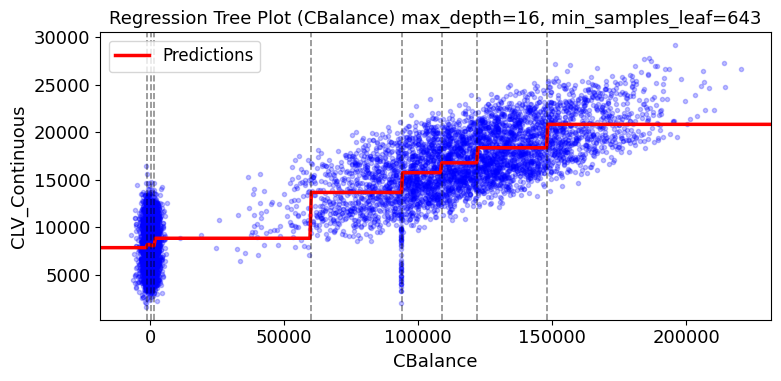

In [45]:
# Separates 1D-Modell mit leichter Regularisierung fuer eine saubere Visualisierung
tree_plot = DecisionTreeRegressor(max_depth=best_tree.get_depth(), min_samples_leaf=best_tree.get_n_leaves(), random_state=RANDOM_STATE)
tree_plot.fit(X_plot_train, y_train)

plt.figure(figsize=(8, 4))
plot_regression_predictions(tree_plot, X_plot_train, y_train, feature_name=feature_for_plot)

thresholds = tree_plot.tree_.threshold
valid_thresholds = thresholds[thresholds != -2]
for split in valid_thresholds:
    plt.axvline(split, color="k", linestyle="--", linewidth=1.2, alpha=0.45)

plt.ylabel("CLV_Continuous")
plt.legend(loc="upper left", fontsize=12)
plt.title(f"Regression Tree Plot ({feature_for_plot}) max_depth={best_tree.get_depth()}, min_samples_leaf={best_tree.get_n_leaves()}")
plt.tight_layout()
plt.show()

### Interpretation der Ergebnisse

#### Overfitting-Analyse: Default vs. Tuned

| Modell | RMSE Train | RMSE Test | R² Train | R² Test | Tiefe | Blätter |
|---|---|---|---|---|---|---|
| Default (kein Tuning) | 0,00 € | 969,14 € | 1,0000 | 0,9685 | 23 | 6.789 |
| **Tuned (GridSearchCV)** | **573,37 €** | **886,47 €** | **0,9889** | **0,9736** | **16** | **643** |

#### Was sagt die Lernkurve? – Overfitting bleibt bestehen

Die Lernkurve zeigt ein **eindeutiges Overfitting-Muster**, auch nach dem Hyperparameter-Tuning:

| Trainingsgröße | Train-RMSE | Validation-RMSE | Gap |
|---|---|---|---|
| 545 | 1.024 € | 1.657 € | 632 € |
| 2.180 | 804 € | 1.280 € | 476 € |
| 5.452 (100%) | 601 € | **991 €** | **390 €** |

Zwei Merkmale sind klar erkennbar:

**1. Großer, persistenter Gap:** Selbst mit allen 5.452 Trainingsbeispielen beträgt der Abstand zwischen Train-RMSE (601 €) und Validation-RMSE (991 €) noch **390 €** – der Validation-Fehler ist **1,65× so hoch** wie der Trainingsfehler. Das ist das klassische Zeichen von Overfitting.

**2. Kein Konvergieren:** Die beiden Kurven nähern sich zwar mit mehr Daten an, aber sie laufen nicht aufeinander zu – der Gap bleibt groß. Laut Vorlesung bedeutet das: *"One way to improve an overfitting model is to feed it more training data until the validation error reaches the training error."* Das wäre hier erst mit erheblich mehr Daten möglich.

> **Zum Vergleich Lasso (Task 5):** Train-RMSE 884 € vs. CV-RMSE 891 € → Gap nur **7 €**. Das zeigt, wie gut Lasso generalisiert, während der Regression Tree trotz Tuning deutlich overfittet.

#### Warum overfittet der Baum trotz GridSearchCV?

GridSearchCV hat `max_depth=None` und `min_samples_leaf=1` als beste Parameter gewählt – der Baum darf also weiterhin tief wachsen und sehr kleine Blätter bilden (16 Ebenen, 643 Blätter). Das `min_samples_split=20` bremst das Wachstum zwar ein, reicht aber nicht aus, um den Gap vollständig zu schließen. Der Baum merkt sich immer noch lokale Muster der Trainingsdaten, die auf neuen Daten nicht zutreffen.

#### Feature Importances

`CBalance` (79,75%) und `CEstimatedSalary` (16,61%) dominieren vollständig. Alle anderen 20 Features tragen zusammen nur ~3,6% bei. Das deckt sich mit den Korrelationsergebnissen aus der Datenanalyse.

#### Fazit

Der **Regression Tree (Tuned)** erzielt auf dem Testset einen RMSE von **886,47 €** (R² = 0,9736). Trotz GridSearchCV liegt **weiterhin Overfitting vor**, wie die Lernkurve eindeutig zeigt (Gap: 390 €, Faktor 1,65×). Das Modell generalisiert schlechter als Lasso aus Task 5.

**→ Regression Tree (Tuned) wird in Task 7 gegen Lasso (Task 5) verglichen.**

---
## Task 7: Modellvergleich & Evaluation

In [52]:
def evaluate_model(model, model_name, cv_rmse):
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)

    return {
        'Modell': model_name,
        'Train MAE': mean_absolute_error(y_train, y_pred_train),
        'Test MAE': mean_absolute_error(y_test, y_pred_test),
        'Train RMSE': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'Train R2': train_r2,
        'Test R2': test_r2,
        'R2-Gap': train_r2 - test_r2,
        'CV-RMSE': cv_rmse
    }

lasso_results = evaluate_model(best_lasso, 'Optimized Lasso Regression', -grid_lasso.best_score_)
tree_results  = evaluate_model(best_tree,  'Optimized Regression Tree',  -tree_grid.best_score_)

comparison_df = pd.DataFrame([lasso_results, tree_results]).set_index('Modell')
pd.set_option('display.float_format', '{:.4f}'.format)
comparison_df

,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2,R2-Gap,CV-RMSE
Modell,,,,,,,,
Optimized Lasso Regression,451.1698,470.1111,884.2363,920.7481,0.9736,0.9715,0.0021,892.8542
Optimized Regression Tree,414.3072,643.7267,573.3683,886.4669,0.9889,0.9736,0.0153,992.1718


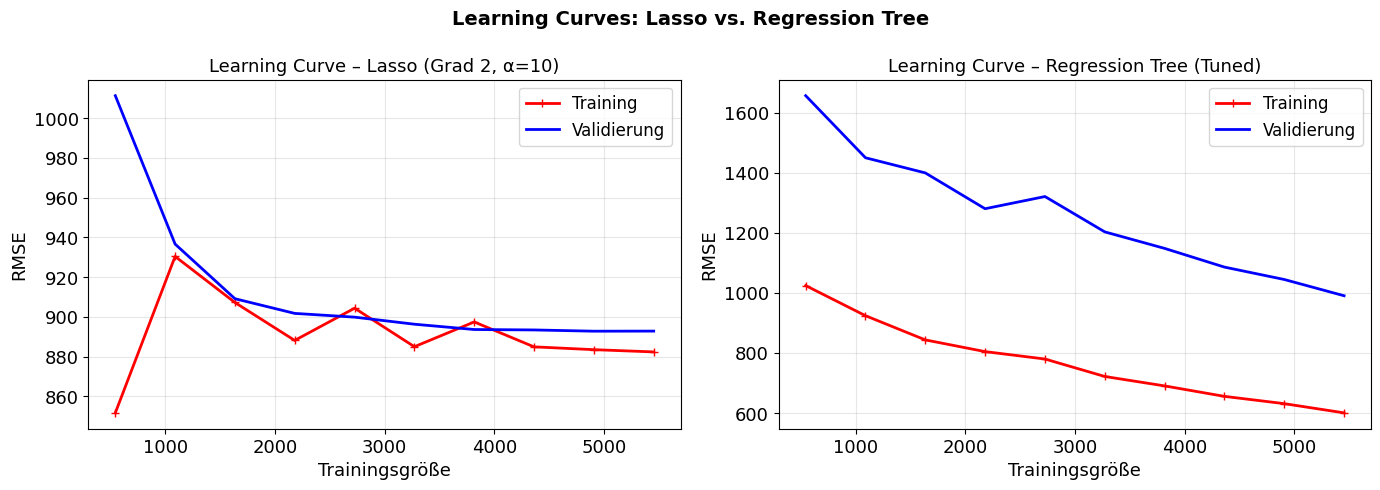

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, title in zip(
    axes,
    [best_lasso, best_tree],
    ['Lasso (Grad 2, α=10)', 'Regression Tree (Tuned)']
):
    sizes, tr_scores, va_scores = learning_curve(
        model, X_train, y_train,
        cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    ax.plot(sizes, -tr_scores.mean(axis=1), 'r-+', linewidth=2, label='Training')
    ax.plot(sizes, -va_scores.mean(axis=1), 'b-',  linewidth=2, label='Validierung')
    ax.set_title(f'Learning Curve – {title}')
    ax.set_xlabel('Trainingsgröße')
    ax.set_ylabel('RMSE')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Learning Curves: Lasso vs. Regression Tree', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

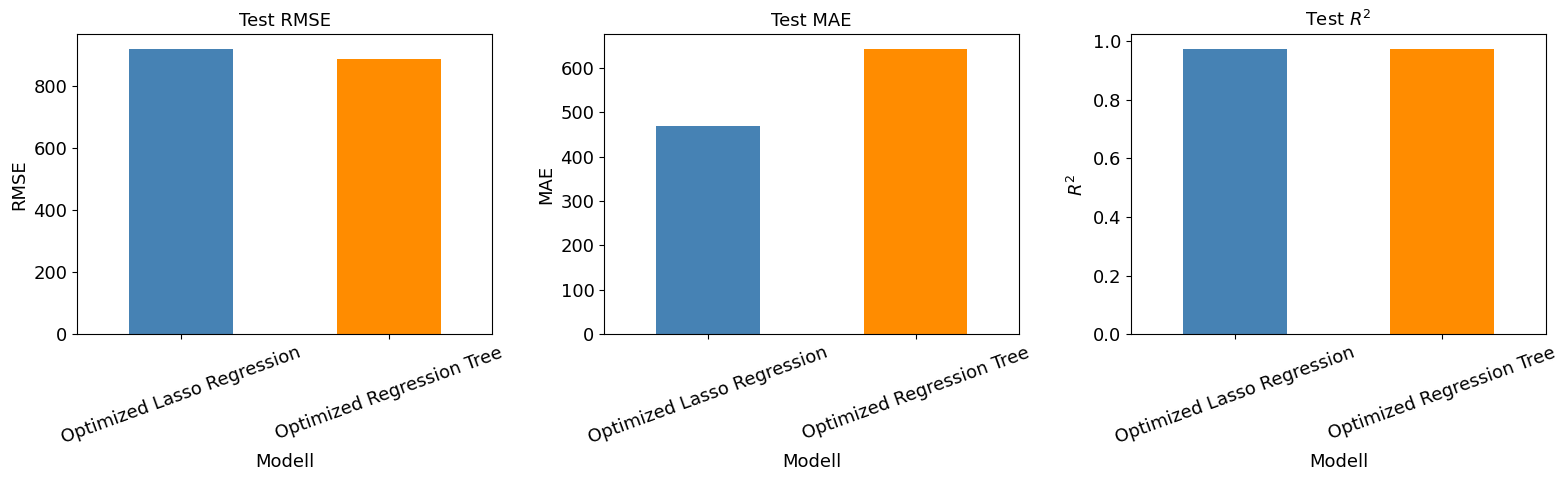

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

comparison_df['Test RMSE'].plot(kind='bar', ax=axes[0], color=['steelblue', 'darkorange'])
axes[0].set_title('Test RMSE')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=20)

comparison_df['Test MAE'].plot(kind='bar', ax=axes[1], color=['steelblue', 'darkorange'])
axes[1].set_title('Test MAE')
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=20)

comparison_df['Test R2'].plot(kind='bar', ax=axes[2], color=['steelblue', 'darkorange'])
axes[2].set_title('Test $R^2$')
axes[2].set_ylabel('$R^2$')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

---
## 9. Interpretation & Modellentscheidung

### 9.1 Vollständiger Metriken-Vergleich

| Metrik | Lasso (Grad 2, α=10) | Regression Tree | Sieger |
|---|---|---|---|
| RMSE Train | 884,24 € | 573,37 € | Tree |
| **RMSE Test** | **920,75 €** | **886,47 €** | **Tree** |
| R² Train | 0,9736 | 0,9889 | Tree |
| R² Test | 0,9715 | 0,9736 | Tree |
| **R²-Gap (Train−Test)** | **0,0021** | **0,0153** | **Lasso** |
| **CV RMSE** | **892,85 ± 21,38** | **992,17 ± 39,81** | **Lasso** |

### 9.2 Der entscheidende Widerspruch – und wie er aufzulösen ist

Auf den ersten Blick scheint der Regression Tree zu gewinnen: Er hat einen besseren Test-RMSE (886 € vs. 921 €) und ein höheres Test-R² (0,9736 vs. 0,9715). Doch dieser Befund ist **irreführend**, sobald man CV-RMSE und Learning Curve hinzuzieht.

**CV RMSE – das robustere Maß:**  
Der CV-RMSE des Regression Trees (992 €) liegt **99 € über** dem von Lasso (893 €). Die Cross-Validation teilt die Trainingsdaten in 5 Folds auf und misst die durchschnittliche Generalisierungsfähigkeit über verschiedene Datensplits. Dieser Wert ist robuster als ein einzelner Test-Split.

> **Warum ist der Test-RMSE des Trees besser, obwohl er overfittet?**  
> Der Test-Split ist **nur ein einziger** zufälliger Datenschnitt. Es ist möglich, dass dieser spezifische 20%-Split zufällig gut für den Tree passt. Der CV-RMSE über 5 verschiedene Splits zeigt das wahre Bild.

**Learning Curve – das visuelle Beweisstück:**  
- **Lasso:** Train- und Validierungskurve konvergieren eng → Gap bleibt minimal → kein Overfitting
- **Regression Tree:** Großer, persistenter Gap (390 € bei voller Trainingsgröße, Faktor 1,65×) → klassisches Overfitting, auch nach Tuning

**R²-Gap als Overfitting-Indikator:**  
Der R²-Gap des Trees (0,0153) ist **7× größer** als der von Lasso (0,0021). Das Modell lernt Trainingsdaten deutlich besser als es auf neuen Daten generalisiert.

### 9.3 Warum generalisiert Lasso besser?

Lasso setzt 219 von 275 Features auf exakt 0 und arbeitet nur mit 56 relevanten Features. Es erzwingt ein **sparsames, robustes Modell**, das nur die echten Signale nutzt. Der Regression Tree hingegen baut komplexe Splits über alle Features und reagiert auf lokale Muster in den Trainingsdaten, die auf neuen Daten nicht existieren.

Lasso profitiert zudem von der **PolynomialFeatures(Grad 2)**-Transformation, die gezielt nichtlineare Zusammenhänge erfasst – ohne das Overfitting-Risiko eines tiefen Baums.

### 9.4 Entscheidung: Lasso ist das bessere Modell

**Lasso Regression (Grad 2, α = 10)** wird als Gesamtsieger gewählt. Die Begründung:

1. **Besserer CV-RMSE** (892,85 €) – robustester Maßstab für Generalisierungsfähigkeit, 99 € besser als der Tree
2. **Kein Overfitting** – R²-Gap von nur 0,0021, Learning Curve zeigt enge Konvergenz
3. **Geringere Streuung** – CV-Standardabweichung 21,38 € vs. 39,81 € beim Tree → stabileres Modell
4. **Sparsamkeit** – 56 statt 643 aktive Parameter, leichter interpretierbar und wartbar

Der bessere Test-RMSE des Trees auf diesem einzelnen Split ist kein ausreichendes Gegenargument, da er durch das nachgewiesene Overfitting erklärbar ist.

**→ Lasso (Grad 2, α = 10) wird als bestes Regressionsmodell für Task 8 (Ensemble Learning) übergeben.**

---
### Schritt 5: Interpretation und Schlussfolgerung

#### Welche Modelle sind in welchen Aspekten besser?
- Der **optimierte Regressionsbaum** erzielt die bessere **Testleistung** bei **RMSE** und **$R^2$**.
- Die **optimierte Ridge Regression** erzielt den besseren **MAE**, den kleineren **Train-Test-Gap** und den deutlich besseren **CV-RMSE**.

#### Warum schneidet der Regressionsbaum bei RMSE und $R^2$ besser ab?
- Entscheidungsbaeume koennen **nichtlineare Zusammenhaenge** und **komplexe Interaktionen** direkt modellieren.
- In diesem Datensatz scheint der CLV stark durch nichtlineare Schwellen und Segmentierungen beeinflusst zu sein, was dem Baum entgegenkommt.
- Die hohe Bedeutung von `CBalance` und `CEstimatedSalary` zeigt, dass wenige dominante Split-Variablen bereits viel Struktur erklaeren.

#### Warum ist Ridge trotzdem stabiler?
- Ridge Regression ist ein **glatteres und robusteres Modell**.
- Der kleinere Train-Test-Gap und der niedrigere CV-RMSE zeigen, dass Ridge auf verschiedenen Folds **stabiler generalisiert**.
- Das spricht dafuer, dass der Regressionsbaum trotz besserer Testwerte noch etwas staerker zur Varianz neigt.

#### Schlussfolgerung
- **Nach reiner Testleistung** ist der **optimierte Regressionsbaum** das bessere Modell.
- **Nach Robustheit und Stabilitaet** ist die **optimierte Ridge Regression** die sicherere Wahl.
- Wenn der Fokus auf der bestmoeglichen Vorhersage auf diesem Testsplit liegt, ist der Regressionsbaum vorzuziehen. Wenn dagegen ein stabileres und besser kontrollierbares Modell gewuenscht ist, spricht mehr fuer Ridge Regression.